# 1. Data Loading & Cleaning

In [62]:
# Imports neccessary libraries that this project uses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub


In [63]:
path = kagglehub.dataset_download("munumbutt/superconductor-dataset")
for i in os.listdir(path):
    print(i) # Downloads and prints the csv name from kaggle

df = pd.read_csv(os.path.join(path, "train.csv")) # Load the dataset into a DataFrame (df) so we can work with it in pandas.

print(df.shape) # Prints the number of rows and columns in the data
print(df.info()) #Column names, data types and non null counts
print(df.isna().sum()) # Counts how many missing values (we dont have any)
print(df.duplicated().sum()) # counts exact duplicate rows (we have 66)
print(df.describe())  # summary stats (mean, std, min, max, quartiles) per numeric column - used to spot outliers, weird values, or scale differences
df.head() # This prints the first 5 rows of each column


train.csv
(21263, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [64]:
# Were just getting rid of those 66 duplicates now

Before = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {Before - df.shape[0]} duplicates, {df.shape[0]} rows left")

Removed 66 duplicates, 21197 rows left


# 2. Exploratory Data Analysis: Target Distribution

count    21197.00
mean        34.49
std         34.28
min          0.00
25%          5.38
50%         20.00
75%         63.00
max        185.00
Name: critical_temp, dtype: float64
Skewness:  0.86


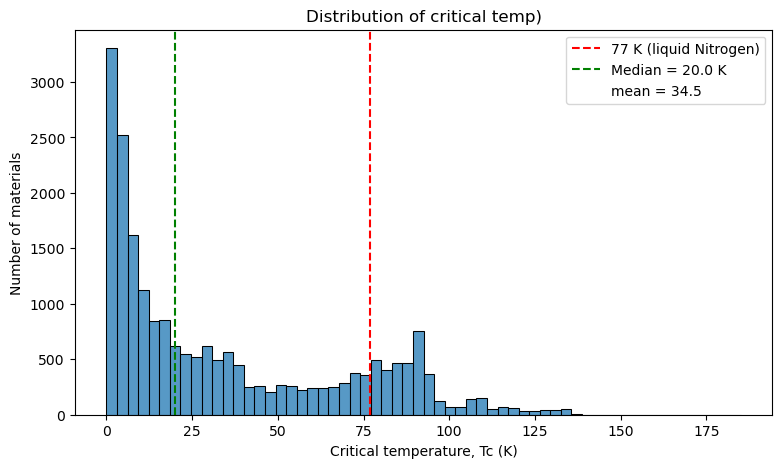

In [65]:
tc = df["critical_temp"] #tc means "critical temperature" so we dont have to keep typing out df[xx] whenever we want it 

print(tc.describe().round(2))
print(f"Skewness: {tc.skew(): .2f}") #measures how lopsided our distribution is 

fig, ax = plt.subplots(figsize=(9, 5)) # creates the figure and the one are plot
sns.histplot(tc, bins=60, ax=ax)
ax.axvline(77, color="red", linestyle="--", label="77 K (liquid Nitrogen)")  # sets line at 77K
ax.axvline(tc.median(), color="green", linestyle="--", label=f"Median = {tc.median():.1f} K") # Line at 
ax.axvline(tc.mean(), color="black", linestyle="", label=f"mean = {tc.mean():.1f}")

ax.set_xlabel("Critical temperature, Tc (K)") #Labels x axis
ax.set_ylabel("Number of materials") #Y axis
ax.set_title("Distribution of critical temp)") 
ax.legend()
plt.show()



In [66]:
above_77K = (tc > 77).mean() * 100
print(f"{above_77K:.1f}% of materials above 77 Kelvin with {(tc > 77).sum()} materials")

18.4% of materials above 77 Kelvin with 3894 materials



Tc ranges from near 0 K to 185 K, with a median of 20.0 K and a mean of 34.5 K. The distribution is right-skewed (skewness 0.86) and bimodal: most materials sit below 15 K, with a second cluster around 75–95 K, likely the cuprate family. 18.4% of materials (3,894) have Tc above 77 K, the boiling point of liquid nitrogen, so the classification task in section 6 is moderately imbalanced.


# 3. Exploratory Data Analysis: Feature Relationships

In [67]:
corr = df.corr()["critical_temp"].drop("critical_temp") # Correlation of every column with Tc, removing Tc itself
corr = corr.sort_values(key=abs, ascending=False) # Sort by strength, ignoring sign (-0.6 counts as strong as 0.6)

spearman = df.corr(method="spearman")["critical_temp"].drop("critical_temp") # Rank-based version, better for skewed data

corr_table = pd.DataFrame({"pearson": corr, "spearman": spearman[corr.index]}).round(2) # Both side by side, same order
corr_table.head(20) # Show the top 20

,pearson,spearman
wtd_std_ThermalConductivity,0.72,0.71
range_ThermalConductivity,0.69,0.72
range_atomic_radius,0.65,0.75
std_ThermalConductivity,0.65,0.62
wtd_mean_Valence,-0.63,-0.74
wtd_entropy_atomic_mass,0.63,0.71
wtd_gmean_Valence,-0.62,-0.74
wtd_entropy_atomic_radius,0.60,0.69
number_of_elements,0.60,0.67
range_fie,0.60,0.66


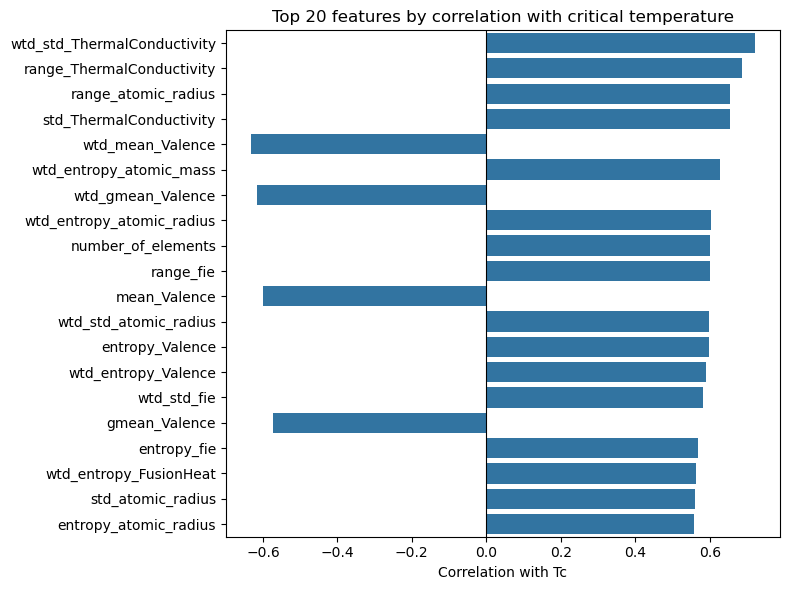

In [68]:
top20 = corr.head(20) # The 20 strongest correlations

plt.figure(figsize=(8, 6))
sns.barplot(x=top20.values, y=top20.index) # Horizontal bars so the long feature names fit
plt.axvline(0, color="black", linewidth=0.8) # Line at zero separates positive and negative correlations
plt.xlabel("Correlation with Tc")
plt.ylabel("") #without it, y label was saying "none"
plt.title("Top 20 features by correlation with critical temperature")
plt.tight_layout() # Stops labels getting cut off
plt.show()

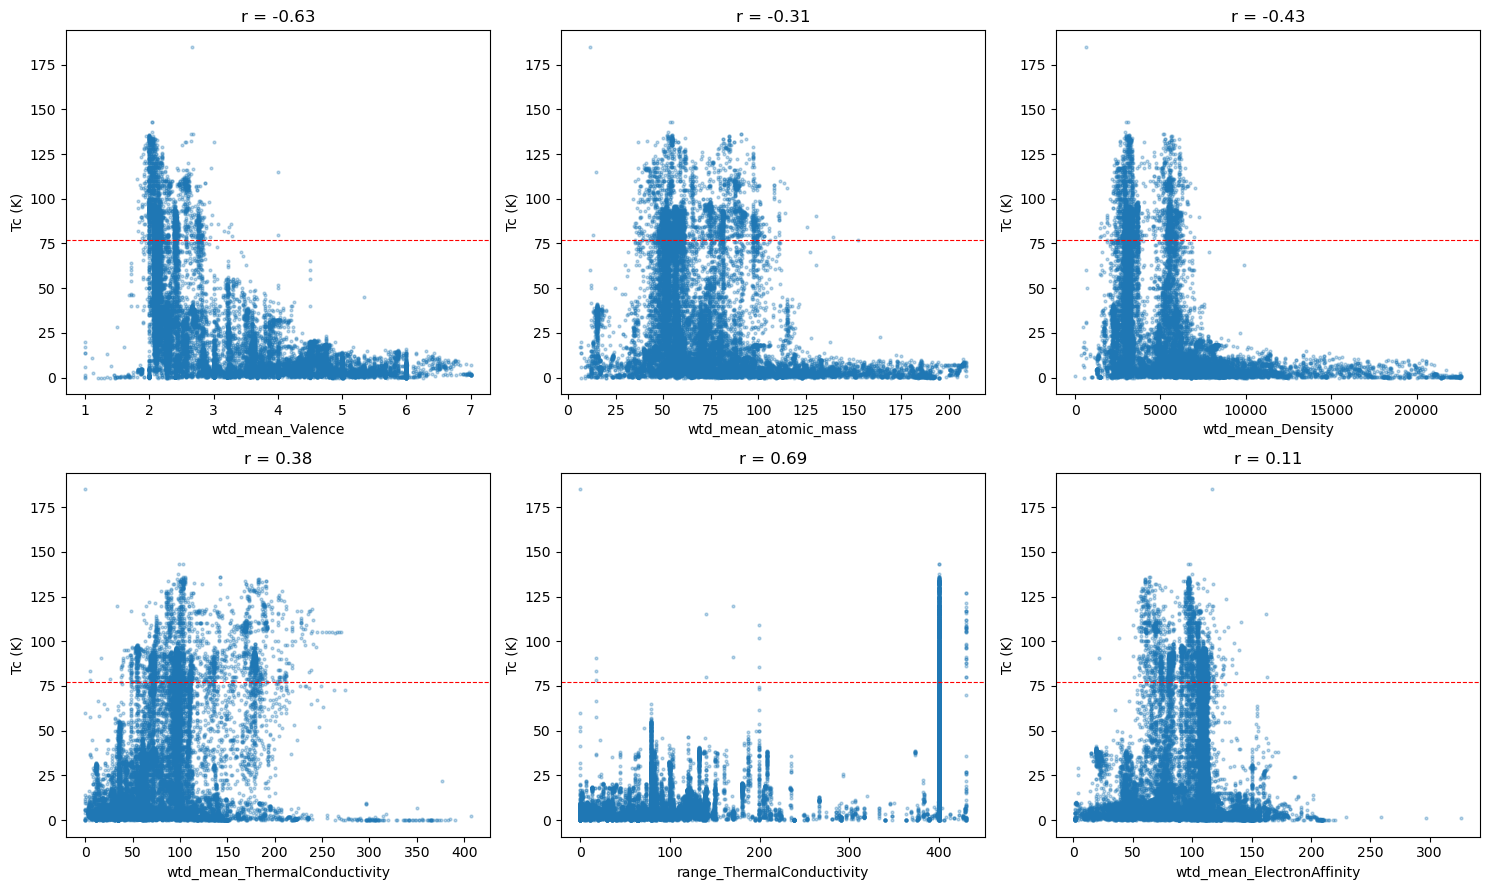

In [69]:
features = ["wtd_mean_Valence", "wtd_mean_atomic_mass", "wtd_mean_Density",
            "wtd_mean_ThermalConductivity", "range_ThermalConductivity", "wtd_mean_ElectronAffinity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9)) # Grid of 2 rows x 3 columns of plots
for ax, feat in zip(axes.flat, features): # Loop through each plot area and feature together
    ax.scatter(df[feat], tc, s=4, alpha=0.3) # Small, see-through dots so dense areas show up
    ax.axhline(77, color="red", linestyle="--", linewidth=0.8) # 77 K line for reference
    ax.set_xlabel(feat)
    ax.set_ylabel("Tc (K)")
    ax.set_title(f"r = {df[feat].corr(tc):.2f}") # Correlation value in the title
plt.tight_layout()
plt.show()

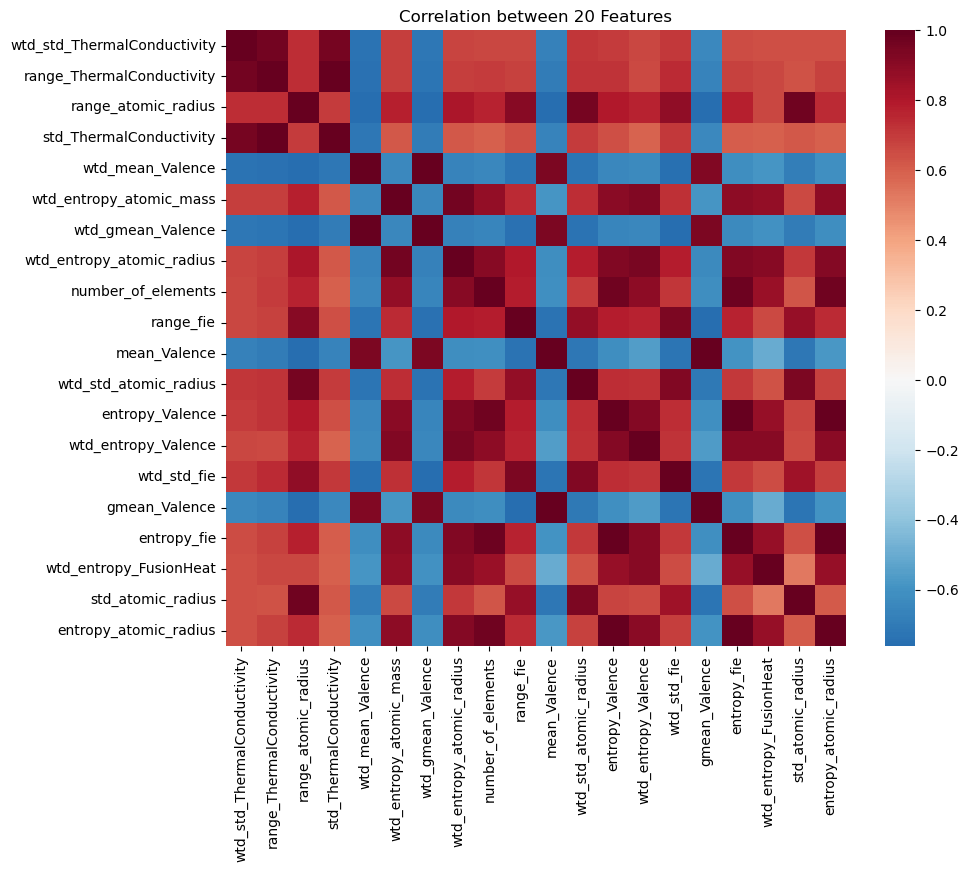

In [78]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[top20.index].corr(), cmap="RdBu_r", center =0) 
plt.title("Correlation between 20 Features")
plt.show()


The top 20 features are highly inter-correlated and fall into roughly four groups: thermal conductivity spread, mean valence, compositional complexity (entropy features and number of elements), and atomic radius / ionisation energy spread. Features within each group carry largely the same information, so feature importance in section 5 will be interpreted at the level of property groups rather than individual features.

Dark red means when one goes up so does the other, blue means if one goes up the other goes down. white means if one goes up it doesnt effect the other

# 4. Regression Modelling